# Se desarrolló un sistema que no solo predice la demanda, sino que optimiza niveles de inventario considerando incertidumbre y tiempos de reposición

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/outputs/predictions.csv", parse_dates=["date"])
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,dayofweek,weekofyear,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,predictions
0,2023-01-06,store_5,item_2,46,46.48,1,4,1,2023,6,4,1,40.0,35.0,30.0,39.0,42.571429,41.357143,16.621844,51.502204
1,2023-01-06,store_12,item_22,22,49.41,0,4,1,2023,6,4,1,29.0,32.0,22.0,19.0,26.571429,25.857143,4.237025,22.774752
2,2023-01-06,store_3,item_45,60,56.96,1,4,1,2023,6,4,1,51.0,36.0,34.0,41.0,48.714286,49.642857,12.120427,61.917684
3,2023-01-06,store_8,item_4,75,19.32,1,4,1,2023,6,4,1,84.0,47.0,54.0,61.0,60.285714,58.642857,14.185841,78.319572
4,2023-01-06,store_40,item_49,12,53.38,0,4,1,2023,6,4,1,14.0,12.0,12.0,14.0,14.142857,13.357143,1.864454,12.035145


In [3]:
# Definimos variables de negocio
lead_time = 7  # días en reabastecer
service_level = 0.95  # nivel de servicio (95%)
z = 1.65  # valor z para 95%

In [ ]:
# Demanda durante lead time
df["demand_lead_time"] = df["predictions"] * lead_time

In [5]:
# Variabilidad de la demanda
df["std_lead_time"] = df["rolling_std_7"] * np.sqrt(lead_time)

In [6]:
# Stock de seguridad
df["safety_stock"] = z * df["std_lead_time"]

In [7]:
# Stock óptimo
df["optimal_stock"] = df["demand_lead_time"] + df["safety_stock"]

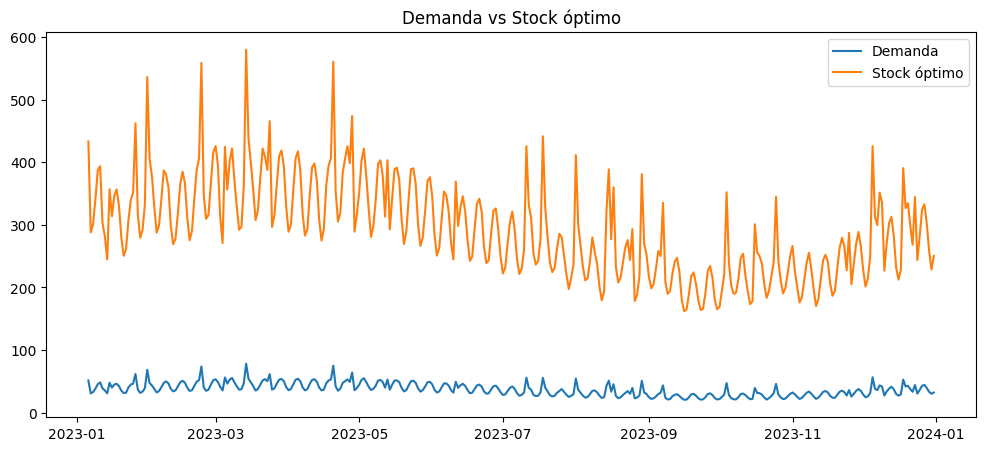

In [8]:
import matplotlib.pyplot as plt

sample = df[
    (df["store_id"] == df["store_id"].iloc[0]) &
    (df["item_id"] == df["item_id"].iloc[0])
]

plt.figure(figsize=(12,5))
plt.plot(sample["date"], sample["predictions"], label="Demanda")
plt.plot(sample["date"], sample["optimal_stock"], label="Stock óptimo")
plt.legend()
plt.title("Demanda vs Stock óptimo")
plt.show()

In [9]:
df.to_csv("/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/outputs/inventory_optimization.csv", index=False)